# Module 1: Natural Language to Category (NLC) Model

## WanderWise+ - Intelligent Tourism Route Planning

This notebook implements a complete NLC pipeline that converts user natural language input into structured interest categories for Goa tourism.

### Categories:
1. **beaches** - Coastal areas, water activities
2. **historical** - Forts, churches, temples, monuments
3. **adventure** - Water sports, trekking, extreme activities
4. **nature** - Wildlife, waterfalls, plantations
5. **food** - Restaurants, local cuisine, food tours
6. **nightlife** - Clubs, bars, casinos, parties
7. **shopping** - Markets, handicrafts, souvenirs

---

## 1. Setup and Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss
)

# Model persistence
import joblib
import json
import os
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


### 1.1 Configuration Constants

In [2]:
# Random seed for reproducibility
RANDOM_STATE = 42

# TF-IDF parameters
MAX_FEATURES = 2000          # Maximum vocabulary size
MIN_DF = 2                   # Minimum document frequency
MAX_DF = 0.95                # Maximum document frequency (as ratio)
NGRAM_RANGE = (1, 2)         # Unigrams and bigrams

# Train-test split
TEST_SIZE = 0.2              # 20% for testing

# Model parameters
SOLVER = 'liblinear'         # Good for small datasets
C_VALUE = 1.0                # Regularization strength
THRESHOLD = 0.5              # Classification threshold

# Category names
CATEGORIES = ['beaches', 'historical', 'adventure', 'nature', 'food', 'nightlife', 'shopping']

# File paths
DATA_PATH = 'new_nlc.csv'  # Enhanced dataset with realistic user inputs
MODEL_OUTPUT_DIR = 'backend/app/models/nlc/'

print("Configuration set!")
print(f"Categories: {CATEGORIES}")
print(f"Number of categories: {len(CATEGORIES)}")

Configuration set!
Categories: ['beaches', 'historical', 'adventure', 'nature', 'food', 'nightlife', 'shopping']
Number of categories: 7


---
## 2. Data Loading and Exploration

### 2.1 Load Dataset

In [ ]:
# Load the training data
df = pd.read_csv(DATA_PATH)


print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (6146, 8)

Column names: ['text', 'beaches', 'historical', 'adventure', 'nature', 'food', 'nightlife', 'shopping']

First 5 rows:


,text,beaches,historical,adventure,nature,food,nightlife,shopping
0,Cavatina looks great,0,0,0,0,1,0,0
1,best beach resort for fam w kids?,1,0,0,0,0,0,0
2,"wildlife mat dikhao, kuch aur chahiye",0,0,0,0,0,0,0
3,Going to LPK Waterfront,0,0,0,0,0,1,0
4,Want to try Basilica of Bom Jesus,0,1,0,0,0,0,0


### 2.2 Basic Statistics

In [4]:
print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)

print(f"\nTotal samples: {len(df)}")
print(f"Total features: {len(df.columns) - 1} (text + 7 category labels)")

# Category distribution
print("\n" + "-" * 30)
print("CATEGORY DISTRIBUTION")
print("-" * 30)
category_counts = df[CATEGORIES].sum().sort_values(ascending=False)
for cat, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{cat:15s}: {count:4d} samples ({percentage:.1f}%)")

# Multi-label distribution
print("\n" + "-" * 30)
print("MULTI-LABEL DISTRIBUTION")
print("-" * 30)
df['num_labels'] = df[CATEGORIES].sum(axis=1)
label_counts = df['num_labels'].value_counts().sort_index()
for num_labels, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{int(num_labels)} label(s): {count:4d} samples ({percentage:.1f}%)")

# Text length statistics
print("\n" + "-" * 30)
print("TEXT LENGTH STATISTICS")
print("-" * 30)
df['text_length'] = df['text'].str.len()
print(f"Min length: {df['text_length'].min()} characters")
print(f"Max length: {df['text_length'].max()} characters")
print(f"Mean length: {df['text_length'].mean():.1f} characters")
print(f"Median length: {df['text_length'].median():.1f} characters")

DATASET STATISTICS

Total samples: 6146
Total features: 7 (text + 7 category labels)

------------------------------
CATEGORY DISTRIBUTION
------------------------------
beaches        : 1157 samples (18.8%)
nature         : 1124 samples (18.3%)
adventure      : 1115 samples (18.1%)
food           : 1106 samples (18.0%)
nightlife      : 1098 samples (17.9%)
historical     : 1094 samples (17.8%)
shopping       : 1013 samples (16.5%)

------------------------------
MULTI-LABEL DISTRIBUTION
------------------------------
0 label(s):  572 samples (9.3%)
1 label(s): 4205 samples (68.4%)
2 label(s):  668 samples (10.9%)
3 label(s):  673 samples (11.0%)
4 label(s):   15 samples (0.2%)
5 label(s):    4 samples (0.1%)
6 label(s):    4 samples (0.1%)
7 label(s):    1 samples (0.0%)
8 label(s):    1 samples (0.0%)
9 label(s):    2 samples (0.0%)
10 label(s):    1 samples (0.0%)

------------------------------
TEXT LENGTH STATISTICS
------------------------------
Min length: 10 characters
Max leng

### 2.3 Visualizations

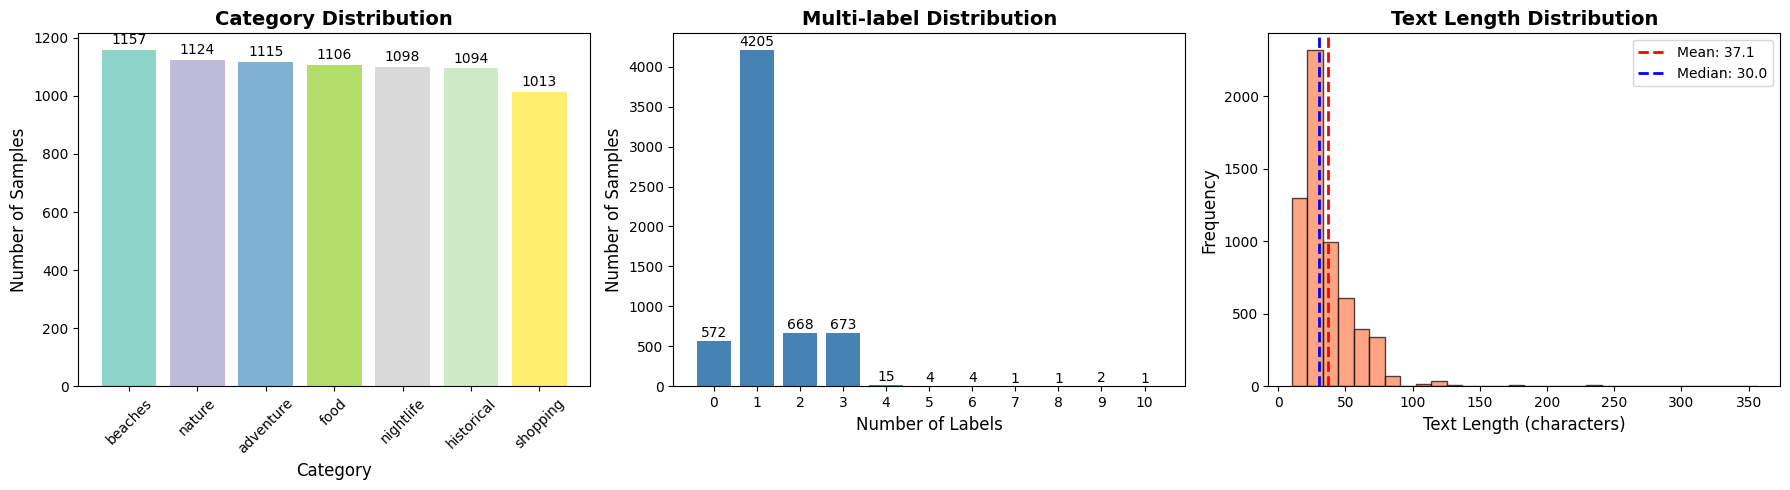


Visualization saved as 'nlc_data_exploration.png'


In [5]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Category Distribution
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(CATEGORIES)))
bars = ax1.bar(category_counts.index, category_counts.values, color=colors)
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Category Distribution', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, category_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontsize=10)

# Plot 2: Multi-label Distribution
ax2 = axes[1]
ax2.bar(label_counts.index, label_counts.values, color='steelblue')
ax2.set_xlabel('Number of Labels', fontsize=12)
ax2.set_ylabel('Number of Samples', fontsize=12)
ax2.set_title('Multi-label Distribution', fontsize=14, fontweight='bold')
ax2.set_xticks(label_counts.index)
for i, count in enumerate(label_counts.values):
    ax2.text(label_counts.index[i], count + 10, str(count), ha='center', va='bottom', fontsize=10)

# Plot 3: Text Length Distribution
ax3 = axes[2]
ax3.hist(df['text_length'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax3.axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["text_length"].mean():.1f}')
ax3.axvline(df['text_length'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df["text_length"].median():.1f}')
ax3.set_xlabel('Text Length (characters)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Text Length Distribution', fontsize=14, fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.savefig('nlc_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nVisualization saved as 'nlc_data_exploration.png'")

### 2.4 Data Quality Checks

In [6]:
print("=" * 50)
print("DATA QUALITY CHECKS")
print("=" * 50)

# Check for missing values
print("\n1. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print(missing[missing > 0])

# Check for empty strings
print("\n2. Empty Strings:")
empty_count = (df['text'].str.strip() == '').sum()
if empty_count == 0:
    print("   ✓ No empty strings found")
else:
    print(f"   ⚠ Found {empty_count} empty strings")

# Check for duplicates
print("\n3. Duplicate Entries:")
duplicate_count = df['text'].duplicated().sum()
if duplicate_count == 0:
    print("   ✓ No duplicate entries found")
else:
    print(f"   ⚠ Found {duplicate_count} duplicate entries")

# Verify label values are binary
print("\n4. Label Values:")
all_binary = True
for cat in CATEGORIES:
    unique_vals = set(df[cat].unique())
    if unique_vals != {0, 1} and unique_vals != {0} and unique_vals != {1}:
        print(f"   ⚠ {cat}: {unique_vals}")
        all_binary = False
if all_binary:
    print("   ✓ All labels are binary (0 or 1)")

# Check for samples with no labels
print("\n5. Samples with No Labels:")
no_label_count = (df[CATEGORIES].sum(axis=1) == 0).sum()
if no_label_count == 0:
    print("   ✓ All samples have at least one label")
else:
    print(f"   ⚠ Found {no_label_count} samples with no labels")

print("\n" + "=" * 50)
print("Data quality check complete!")

DATA QUALITY CHECKS

1. Missing Values:
   ✓ No missing values found

2. Empty Strings:
   ✓ No empty strings found

3. Duplicate Entries:
   ✓ No duplicate entries found

4. Label Values:
   ⚠ beaches: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
   ⚠ historical: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
   ⚠ adventure: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
   ⚠ nature: {np.int64(0), np.int64(1), np.int64(2)}
   ⚠ food: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
   ⚠ shopping: {np.int64(0), np.int64(1), np.int64(2)}

5. Samples with No Labels:
   ⚠ Found 572 samples with no labels

Data quality check complete!


---
## 3. Text Preprocessing

### 3.1 Preprocessing Function

In [7]:
def preprocess_text(text: str) -> str:
    """
    Clean and normalize text for TF-IDF vectorization.
    
    Steps:
    1. Convert to lowercase
    2. Remove punctuation
    3. Remove special characters (keep alphanumeric and spaces)
    4. Remove extra whitespace
    5. Strip leading/trailing whitespace
    
    Args:
        text: Input text string
        
    Returns:
        Preprocessed text string
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove special characters (keep alphanumeric and spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text

# Test the preprocessing function
test_texts = [
    "I LOVE beaches and water sports!",
    "Want to try Goan fish curry & vindaloo...",
    "  Multiple   spaces   and   CAPS  ",
    "What's the best beach in Goa?"
]

print("Preprocessing Examples:")
print("-" * 60)
for original in test_texts:
    processed = preprocess_text(original)
    print(f"Original:  '{original}'")
    print(f"Processed: '{processed}'")
    print()

Preprocessing Examples:
------------------------------------------------------------
Original:  'I LOVE beaches and water sports!'
Processed: 'i love beaches and water sports'

Original:  'Want to try Goan fish curry & vindaloo...'
Processed: 'want to try goan fish curry vindaloo'

Original:  '  Multiple   spaces   and   CAPS  '
Processed: 'multiple spaces and caps'

Original:  'What's the best beach in Goa?'
Processed: 'whats the best beach in goa'



### 3.2 Apply Preprocessing

In [8]:
# Apply preprocessing to all text
df['processed_text'] = df['text'].apply(preprocess_text)

# Display before/after examples
print("Sample Before/After Preprocessing:")
print("=" * 70)
for i in range(5):
    idx = np.random.randint(0, len(df))
    print(f"\nExample {i+1}:")
    print(f"  Before: '{df.loc[idx, 'text']}'")
    print(f"  After:  '{df.loc[idx, 'processed_text']}'")
    labels = [cat for cat in CATEGORIES if df.loc[idx, cat] == 1]
    print(f"  Labels: {labels}")

Sample Before/After Preprocessing:

Example 1:
  Before: 'I'm looking for trekking'
  After:  'im looking for trekking'
  Labels: ['adventure']

Example 2:
  Before: 'nature trails experience'
  After:  'nature trails experience'
  Labels: ['nature']

Example 3:
  Before: 'love wetland'
  After:  'love wetland'
  Labels: ['nature']

Example 4:
  Before: 'Which is better for flyboarding in Goa?'
  After:  'which is better for flyboarding in goa'
  Labels: ['adventure']

Example 5:
  Before: 'Heading to Bambolim Beach'
  After:  'heading to bambolim beach'
  Labels: ['beaches']


---
## 4. TF-IDF Vectorization

### 4.1 TF-IDF Configuration

In [9]:
# Display TF-IDF configuration
print("TF-IDF Vectorizer Configuration:")
print("=" * 50)
print(f"max_features:    {MAX_FEATURES} (vocabulary size)")
print(f"min_df:          {MIN_DF} (ignore terms in < 2 documents)")
print(f"max_df:          {MAX_DF} (ignore terms in > 95% of docs)")
print(f"ngram_range:     {NGRAM_RANGE} (unigrams + bigrams)")
print(f"stop_words:      'english' (remove common words)")
print(f"sublinear_tf:    True (log scaling)")

TF-IDF Vectorizer Configuration:
max_features:    2000 (vocabulary size)
min_df:          2 (ignore terms in < 2 documents)
max_df:          0.95 (ignore terms in > 95% of docs)
ngram_range:     (1, 2) (unigrams + bigrams)
stop_words:      'english' (remove common words)
sublinear_tf:    True (log scaling)


### 4.2 Create and Fit Vectorizer

In [14]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_range=NGRAM_RANGE,
    stop_words='english',
    sublinear_tf=True
)

# Fit and transform the text data
X = tfidf_vectorizer.fit_transform(df['processed_text'])

# Get labels
# After extracting labels
y = df[CATEGORIES].values
y = np.clip(y, 0, 1).astype(int)  # Clip values to [0, 1] range

print(f"Feature matrix shape: {X.shape}")
print(f"Label matrix shape: {y.shape}")
print(f"\nVocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Feature matrix shape: (6146, 2000)
Label matrix shape: (6146, 7)

Vocabulary size: 2000
Number of samples: 6146
Number of features: 2000


### 4.3 Vocabulary Analysis

In [15]:
# Get feature names
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Calculate average TF-IDF score for each term
avg_tfidf = np.asarray(X.mean(axis=0)).flatten()

# Get top 20 terms by average TF-IDF score
top_indices = avg_tfidf.argsort()[-20:][::-1]
top_terms = feature_names[top_indices]
top_scores = avg_tfidf[top_indices]

print("Top 20 Terms by Average TF-IDF Score:")
print("-" * 40)
for i, (term, score) in enumerate(zip(top_terms, top_scores), 1):
    print(f"{i:2d}. {term:20s} {score:.4f}")

# Show sample n-grams
print("\n" + "-" * 40)
print("Sample N-grams in Vocabulary:")
print("-" * 40)

# Unigrams
unigrams = [f for f in feature_names if ' ' not in f]
print(f"\nUnigrams (single words): {len(unigrams)}")
print(f"Examples: {list(unigrams[:10])}")

# Bigrams
bigrams = [f for f in feature_names if ' ' in f]
print(f"\nBigrams (word pairs): {len(bigrams)}")
print(f"Examples: {list(bigrams[:10])}")

Top 20 Terms by Average TF-IDF Score:
----------------------------------------
 1. goa                  0.0341
 2. want                 0.0214
 3. beach                0.0208
 4. looking              0.0170
 5. adventure            0.0147
 6. activities           0.0144
 7. spots                0.0143
 8. trip                 0.0142
 9. food                 0.0141
10. need                 0.0135
11. shopping             0.0133
12. best                 0.0132
13. tours                0.0110
14. nature               0.0108
15. market               0.0104
16. interested           0.0104
17. experience           0.0102
18. im                   0.0102
19. planning             0.0099
20. sports               0.0098

----------------------------------------
Sample N-grams in Vocabulary:
----------------------------------------

Unigrams (single words): 743
Examples: ['10', '12', '5day', 'absolutely', 'accha', 'acchi', 'action', 'active', 'activities', 'adrenaline']

Bigrams (word pairs): 1257

---
## 5. Model Training

### 5.1 Train-Test Split

In [16]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

print("Train-Test Split:")
print("=" * 40)
print(f"Training samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Test size:          {TEST_SIZE * 100}%")
print(f"\nFeature dimensions: {X_train.shape[1]}")
print(f"Number of labels:   {y_train.shape[1]}")

Train-Test Split:
Training samples:   4916
Testing samples:    1230
Test size:          20.0%

Feature dimensions: 2000
Number of labels:   7


### 5.2 Create and Train Model

In [17]:
import time

print("Training Multi-Label Logistic Regression Classifier...")
print("=" * 50)

# Create the classifier
classifier = OneVsRestClassifier(
    LogisticRegression(
        solver=SOLVER,
        C=C_VALUE,
        random_state=RANDOM_STATE,
        max_iter=1000
    )
)

# Train and measure time
start_time = time.time()
classifier.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"✓ Training completed in {training_time:.2f} seconds")
print(f"\nModel Configuration:")
print(f"  Strategy: One-vs-Rest (7 binary classifiers)")
print(f"  Base estimator: Logistic Regression")
print(f"  Solver: {SOLVER}")
print(f"  Regularization (C): {C_VALUE}")

Training Multi-Label Logistic Regression Classifier...
✓ Training completed in 0.07 seconds

Model Configuration:
  Strategy: One-vs-Rest (7 binary classifiers)
  Base estimator: Logistic Regression
  Solver: liblinear
  Regularization (C): 1.0


### 5.3 Training Set Performance

In [18]:
# Predictions on training set
y_train_pred = classifier.predict(X_train)

# Calculate training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_hamming = hamming_loss(y_train, y_train_pred)
train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
train_f1_micro = f1_score(y_train, y_train_pred, average='micro')

print("Training Set Performance:")
print("=" * 40)
print(f"Accuracy:       {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Hamming Loss:   {train_hamming:.4f}")
print(f"Macro F1:       {train_f1_macro:.4f}")
print(f"Micro F1:       {train_f1_micro:.4f}")

Training Set Performance:
Accuracy:       0.6806 (68.06%)
Hamming Loss:   0.0643
Macro F1:       0.7856
Micro F1:       0.7855


---
## 6. Model Evaluation

### 6.1 Test Set Predictions

In [19]:
# Make predictions on test set
y_pred = classifier.predict(X_test)
y_pred_proba = classifier.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Probabilities shape: {y_pred_proba.shape}")
print(f"\nSample predictions (first 5):")
for i in range(5):
    predicted_cats = [CATEGORIES[j] for j, val in enumerate(y_pred[i]) if val == 1]
    actual_cats = [CATEGORIES[j] for j, val in enumerate(y_test[i]) if val == 1]
    print(f"  Sample {i+1}: Predicted={predicted_cats}, Actual={actual_cats}")

Predictions shape: (1230, 7)
Probabilities shape: (1230, 7)

Sample predictions (first 5):
  Sample 1: Predicted=['historical'], Actual=['historical']
  Sample 2: Predicted=['adventure'], Actual=['adventure']
  Sample 3: Predicted=['nature', 'shopping'], Actual=['nature', 'shopping']
  Sample 4: Predicted=['historical'], Actual=['historical']
  Sample 5: Predicted=['food'], Actual=['food']


### 6.2 Overall Metrics

In [20]:
# Calculate overall metrics
accuracy = accuracy_score(y_test, y_pred)
hamming = hamming_loss(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')

print("=" * 50)
print("TEST SET EVALUATION METRICS")
print("=" * 50)
print(f"\nOverall Metrics:")
print(f"  Accuracy:           {accuracy:.4f} ({{accuracy*100:.2f}}%)")
print(f"  Hamming Loss:       {hamming:.4f}")
print(f"\nF1 Scores:")
print(f"  Macro F1:           {macro_f1:.4f}")
print(f"  Micro F1:           {micro_f1:.4f}")
print(f"  Weighted F1:        {weighted_f1:.4f}")
print(f"\nPrecision & Recall:")
print(f"  Macro Precision:    {macro_precision:.4f}")
print(f"  Macro Recall:       {macro_recall:.4f}")

TEST SET EVALUATION METRICS

Overall Metrics:
  Accuracy:           0.5829 ({accuracy*100:.2f}%)
  Hamming Loss:       0.0828

F1 Scores:
  Macro F1:           0.7114
  Micro F1:           0.7117
  Weighted F1:        0.7113

Precision & Recall:
  Macro Precision:    0.9473
  Macro Recall:       0.5703


### 6.3 Per-Category Metrics

In [21]:
# Calculate per-category metrics
print("Per-Category Performance:")
print("=" * 70)
print(f"{'Category':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 70)

per_category_metrics = []
for i, cat in enumerate(CATEGORIES):
    precision = precision_score(y_test[:, i], y_pred[:, i])
    recall = recall_score(y_test[:, i], y_pred[:, i])
    f1 = f1_score(y_test[:, i], y_pred[:, i])
    support = y_test[:, i].sum()
    
    per_category_metrics.append({
        'category': cat,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support
    })
    
    print(f"{cat:<15} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {int(support):>10}")

print("-" * 70)

Per-Category Performance:
Category         Precision     Recall   F1-Score    Support
----------------------------------------------------------------------
beaches             0.9589     0.6140     0.7487        228
historical          0.9615     0.5605     0.7082        223
adventure           0.8926     0.5808     0.7037        229
nature              0.9531     0.5622     0.7072        217
food                0.9496     0.5067     0.6608        223
nightlife           0.9685     0.5885     0.7321        209
shopping            0.9466     0.5794     0.7188        214
----------------------------------------------------------------------


### 6.4 Classification Report

In [22]:
# Full classification report
print("Classification Report:")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

Classification Report:
              precision    recall  f1-score   support

     beaches       0.96      0.61      0.75       228
  historical       0.96      0.56      0.71       223
   adventure       0.89      0.58      0.70       229
      nature       0.95      0.56      0.71       217
        food       0.95      0.51      0.66       223
   nightlife       0.97      0.59      0.73       209
    shopping       0.95      0.58      0.72       214

   micro avg       0.95      0.57      0.71      1543
   macro avg       0.95      0.57      0.71      1543
weighted avg       0.95      0.57      0.71      1543
 samples avg       0.68      0.59      0.61      1543



### 6.5 Confusion Matrices

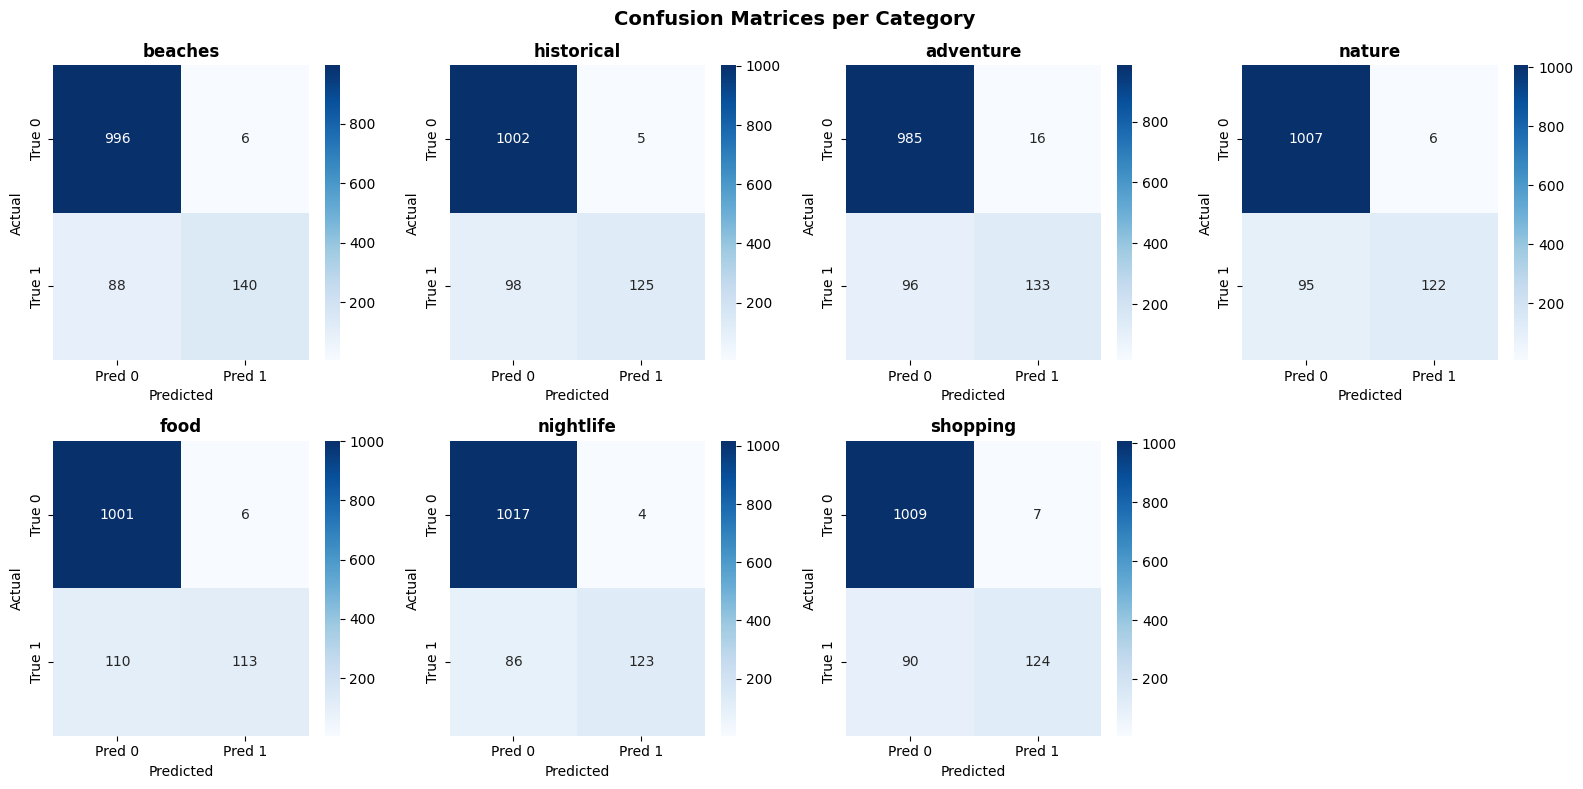


Confusion matrices saved as 'nlc_confusion_matrices.png'


In [23]:
# Create confusion matrices for each category
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    axes[i].set_title(f'{cat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the last subplot (8 subplots for 7 categories)
axes[7].axis('off')

plt.suptitle('Confusion Matrices per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nlc_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nConfusion matrices saved as 'nlc_confusion_matrices.png'")

### 6.6 F1 Score Visualization

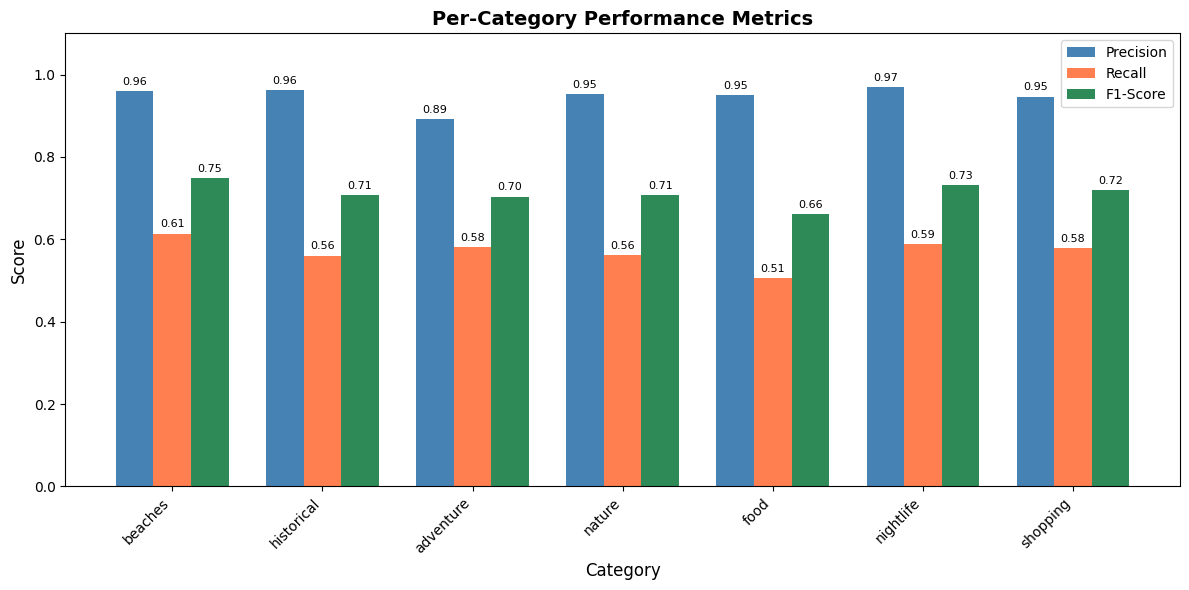


F1 scores visualization saved as 'nlc_f1_scores.png'


In [24]:
# Create F1 score bar chart
fig, ax = plt.subplots(figsize=(12, 6))

categories = [m['category'] for m in per_category_metrics]
f1_scores = [m['f1'] for m in per_category_metrics]
precisions = [m['precision'] for m in per_category_metrics]
recalls = [m['recall'] for m in per_category_metrics]

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x, recalls, width, label='Recall', color='coral')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='seagreen')

ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Category Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('nlc_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nF1 scores visualization saved as 'nlc_f1_scores.png'")

### 6.7 Error Analysis

In [25]:
# Analyze misclassifications
print("Error Analysis:")
print("=" * 60)

# Find misclassified samples
misclassified_indices = np.where((y_test != y_pred).any(axis=1))[0]
print(f"\nTotal misclassified samples: {len(misclassified_indices)} out of {len(y_test)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_test)*100:.2f}%")

# Show some misclassified examples
print("\nSample Misclassifications:")
print("-" * 60)

# Get original indices
test_indices = np.arange(len(df))
_, test_indices = train_test_split(test_indices, test_size=TEST_SIZE, random_state=RANDOM_STATE)

for i in misclassified_indices[:5]:
    original_idx = test_indices[i]
    text = df.iloc[original_idx]['text']
    actual = [CATEGORIES[j] for j, val in enumerate(y_test[i]) if val == 1]
    predicted = [CATEGORIES[j] for j, val in enumerate(y_pred[i]) if val == 1]
    
    print(f"\nText: '{text}'")
    print(f"  Actual:    {actual}")
    print(f"  Predicted: {predicted}")

Error Analysis:

Total misclassified samples: 513 out of 1230
Misclassification rate: 41.71%

Sample Misclassifications:
------------------------------------------------------------

Text: 'College reunion trip, looking for adventure sports activities for 10 people'
  Actual:    ['historical', 'adventure']
  Predicted: ['adventure']

Text: 'sandy spots recomendations pls'
  Actual:    ['beaches', 'shopping']
  Predicted: []

Text: 'I want to explore the waterfalls and also enjoy the beach life'
  Actual:    ['beaches', 'nature']
  Predicted: ['beaches']

Text: 'One day in Goa, must-do pubs experiences?'
  Actual:    ['nightlife']
  Predicted: []

Text: 'Can you recommend extreme sports places in North Goa?'
  Actual:    ['adventure', 'food', 'shopping']
  Predicted: ['adventure']


---
## 7. Model Persistence

### 7.1 Create Output Directory

In [26]:
# Create output directory
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
print(f"Output directory created: {MODEL_OUTPUT_DIR}")

Output directory created: backend/app/models/nlc/


### 7.2 Save Model Components

In [27]:
# Save TF-IDF vectorizer
vectorizer_path = os.path.join(MODEL_OUTPUT_DIR, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, vectorizer_path)
print(f"✓ TF-IDF vectorizer saved to: {vectorizer_path}")

# Save classifier
classifier_path = os.path.join(MODEL_OUTPUT_DIR, 'nlc_classifier.joblib')
joblib.dump(classifier, classifier_path)
print(f"✓ Classifier saved to: {classifier_path}")

✓ TF-IDF vectorizer saved to: backend/app/models/nlc/tfidf_vectorizer.joblib
✓ Classifier saved to: backend/app/models/nlc/nlc_classifier.joblib


### 7.3 Save Complete Pipeline

In [28]:
# Create sklearn pipeline
pipeline = Pipeline([
    ('tfidf', tfidf_vectorizer),
    ('classifier', classifier)
])

# Save complete pipeline
pipeline_path = os.path.join(MODEL_OUTPUT_DIR, 'nlc_pipeline.joblib')
joblib.dump(pipeline, pipeline_path)
print(f"✓ Complete pipeline saved to: {pipeline_path}")

✓ Complete pipeline saved to: backend/app/models/nlc/nlc_pipeline.joblib


### 7.4 Save Metadata

In [29]:
# Create metadata
metadata = {
    'model_version': '1.0.0',
    'training_date': datetime.now().isoformat(),
    'num_samples': len(df),
    'num_features': int(MAX_FEATURES),
    'categories': CATEGORIES,
    'tfidf_params': {
        'max_features': MAX_FEATURES,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'ngram_range': NGRAM_RANGE
    },
    'model_params': {
        'solver': SOLVER,
        'C': C_VALUE
    },
    'metrics': {
        'accuracy': float(accuracy),
        'hamming_loss': float(hamming),
        'macro_f1': float(macro_f1),
        'micro_f1': float(micro_f1),
        'macro_precision': float(macro_precision),
        'macro_recall': float(macro_recall)
    },
    'per_category_metrics': [
        {
            'category': m['category'],
            'precision': float(m['precision']),
            'recall': float(m['recall']),
            'f1': float(m['f1']),
            'support': int(m['support'])
        }
        for m in per_category_metrics
    ]
}

# Save metadata
metadata_path = os.path.join(MODEL_OUTPUT_DIR, 'metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved to: {metadata_path}")

✓ Metadata saved to: backend/app/models/nlc/metadata.json


### 7.5 Verify Saved Models

In [30]:
# List saved files
print("Saved Model Files:")
print("=" * 50)
for file in os.listdir(MODEL_OUTPUT_DIR):
    file_path = os.path.join(MODEL_OUTPUT_DIR, file)
    size = os.path.getsize(file_path)
    print(f"  {file:<30} {size/1024:.2f} KB")

Saved Model Files:
  nlc_pipeline_best.joblib       150.96 KB
  metadata.json                  1.87 KB
  tfidf_vectorizer.joblib        80.42 KB
  nlc_pipeline.joblib            193.61 KB
  nlc_classifier.joblib          112.77 KB


---
## 8. Inference Testing

### 8.1 Load Saved Model

In [31]:
# Load the saved pipeline
loaded_pipeline = joblib.load(pipeline_path)
print(f"✓ Pipeline loaded from: {pipeline_path}")

✓ Pipeline loaded from: backend/app/models/nlc/nlc_pipeline.joblib


### 8.2 Prediction Function

In [32]:
def predict_categories(text: str, pipeline, threshold: float = 0.3, top_k: int = None) -> tuple[list, dict]:
    """
    Predict interest categories from natural language text.
    
    Uses both threshold-based and top-k selection for robust multi-label prediction.
    
    Args:
        text: User input string
        pipeline: Trained sklearn pipeline
        threshold: Minimum probability threshold for positive prediction (default: 0.3)
        top_k: If set, always return top k categories by confidence (default: None)
        
    Returns:
        Tuple of (predicted_categories, confidence_scores)
    """
    # Preprocess
    processed = preprocess_text(text)
    
    # Get probabilities
    proba = pipeline.predict_proba([processed])[0]
    
    # Create confidence scores dict
    confidence_scores = {cat: float(proba[i]) for i, cat in enumerate(CATEGORIES)}
    
    # Method 1: Threshold-based selection
    threshold_categories = [cat for cat, score in confidence_scores.items() if score >= threshold]
    
    # Method 2: Top-k selection (if specified)
    if top_k is not None:
        sorted_cats = sorted(confidence_scores.items(), key=lambda x: x[1], reverse=True)
        top_k_categories = [cat for cat, score in sorted_cats[:top_k]]
        
        # Combine both methods: use threshold OR top-k (whichever gives more categories)
        # But ensure we have at least 1 category
        if len(threshold_categories) >= top_k:
            predicted_categories = threshold_categories
        else:
            # Use top-k but filter by minimum threshold of 0.15
            predicted_categories = [cat for cat in top_k_categories if confidence_scores[cat] >= 0.15]
            # Ensure at least 1 category
            if not predicted_categories:
                predicted_categories = [top_k_categories[0]]
    else:
        predicted_categories = threshold_categories
        # Ensure at least 1 category (highest confidence)
        if not predicted_categories:
            predicted_categories = [max(confidence_scores.items(), key=lambda x: x[1])[0]]
    
    return predicted_categories, confidence_scores

### 8.3 Test Cases

In [33]:
# Define test cases
test_cases = [
    "I love beaches and swimming",
    "Want to try Goan fish curry and vindaloo",
    "Looking for nightlife and clubs",
    "Interested in forts and Portuguese churches",
    "Beaches, food, and some adventure activities",
    "Scuba diving and parasailing",
    "Wildlife sanctuary and spice plantations",
    "Shopping for souvenirs at the flea market",
    "I want to visit temples and try local cuisine",
    "Beach parties and casino nights"
]

print("Inference Testing:")
print("=" * 70)

for text in test_cases:
    predicted, confidence = predict_categories(text, loaded_pipeline)
    print(f"\nInput: '{text}'")
    print(f"Predicted categories: {predicted}")
    print(f"Confidence scores: {', '.join([f'{k}={v:.2f}' for k, v in confidence.items() if v > 0.3])}")

Inference Testing:

Input: 'I love beaches and swimming'
Predicted categories: ['beaches']
Confidence scores: beaches=0.97

Input: 'Want to try Goan fish curry and vindaloo'
Predicted categories: ['food']
Confidence scores: food=0.81

Input: 'Looking for nightlife and clubs'
Predicted categories: ['nightlife']
Confidence scores: nightlife=0.99

Input: 'Interested in forts and Portuguese churches'
Predicted categories: ['historical']
Confidence scores: historical=0.80

Input: 'Beaches, food, and some adventure activities'
Predicted categories: ['beaches', 'adventure', 'food']
Confidence scores: beaches=0.73, adventure=0.60, food=0.53

Input: 'Scuba diving and parasailing'
Predicted categories: ['adventure']
Confidence scores: adventure=0.84

Input: 'Wildlife sanctuary and spice plantations'
Predicted categories: ['adventure', 'nature']
Confidence scores: adventure=0.52, nature=0.80

Input: 'Shopping for souvenirs at the flea market'
Predicted categories: ['shopping']
Confidence scores: 

### 8.4 Interactive Testing

In [38]:
# Function for interactive testing
def test_custom_input():
    """Test with custom user input using improved multi-label prediction."""
    print("\n" + "=" * 70)
    print("CUSTOM INPUT TESTING (threshold=0.3, top_k=3)")
    print("=" * 70)
    
    custom_inputs = [
        "I want to relax on the beach and eat seafood",
        "History buff interested in old Portuguese architecture",
        "Adventure seeker looking for water sports and trekking",
        "Night owl wanting to experience Goa's famous nightlife",
        "I want to explore the waterfalls of goa and also explore the beach life and enjoy at night at the beach",
        "I want to explore all the famous churches of goa",
        # "beach, food, and some party at night",
        # "looking for nature trails and local cuisine"
        # "i dont want beaches",
        "i want to explore the wildlife and the forts",
        "avoid crowded places"
    ]
    
    for text in custom_inputs:
        # Use threshold=0.3 and top_k=3 for better multi-label prediction
        predicted, confidence = predict_categories(text, loaded_pipeline, threshold=0.3, top_k=3)
        print(f"\nInput: '{text}'")
        print(f"Predicted: {predicted}")
        
        # Show all confidence scores sorted
        sorted_conf = sorted(confidence.items(), key=lambda x: x[1], reverse=True)
        print(f"All scores: {', '.join([f'{k}={v:.3f}' for k, v in sorted_conf])}")

test_custom_input()


CUSTOM INPUT TESTING (threshold=0.3, top_k=3)

Input: 'I want to relax on the beach and eat seafood'
Predicted: ['beaches', 'food']
All scores: beaches=0.780, food=0.411, nightlife=0.062, nature=0.042, historical=0.039, adventure=0.034, shopping=0.033

Input: 'History buff interested in old Portuguese architecture'
Predicted: ['historical']
All scores: historical=0.850, adventure=0.062, food=0.056, nature=0.048, beaches=0.047, nightlife=0.041, shopping=0.041

Input: 'Adventure seeker looking for water sports and trekking'
Predicted: ['adventure', 'nature']
All scores: adventure=0.967, nature=0.156, beaches=0.062, nightlife=0.059, shopping=0.057, historical=0.055, food=0.048

Input: 'Night owl wanting to experience Goa's famous nightlife'
Predicted: ['nightlife']
All scores: nightlife=0.864, beaches=0.113, adventure=0.072, nature=0.071, food=0.069, historical=0.056, shopping=0.051

Input: 'I want to explore the waterfalls of goa and also explore the beach life and enjoy at night at the

---
## Summary

In [35]:
print("\n" + "=" * 70)
print("MODULE 1 NLC MODEL - TRAINING SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset:")
print(f"   Total samples: {len(df)}")
print(f"   Categories: {len(CATEGORIES)}")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Testing samples: {X_test.shape[0]}")

print(f"\n🔧 Model Configuration:")
print(f"   Vectorizer: TF-IDF (max_features={MAX_FEATURES}, ngrams={NGRAM_RANGE})")
print(f"   Classifier: One-vs-Rest Logistic Regression")
print(f"   Solver: {SOLVER}")

print(f"\n📈 Performance Metrics:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Macro F1: {macro_f1:.4f}")
print(f"   Micro F1: {micro_f1:.4f}")
print(f"   Hamming Loss: {hamming:.4f}")

print(f"\n💾 Saved Artifacts:")
print(f"   Directory: {MODEL_OUTPUT_DIR}")
print(f"   - tfidf_vectorizer.joblib")
print(f"   - nlc_classifier.joblib")
print(f"   - nlc_pipeline.joblib")
print(f"   - metadata.json")

print(f"\n✅ Model training complete!")
print(f"\nNext steps:")
print(f"   1. Integrate model into backend API")
print(f"   2. Create NLC service class")
print(f"   3. Add API endpoint for interest classification")


MODULE 1 NLC MODEL - TRAINING SUMMARY

📊 Dataset:
   Total samples: 6146
   Categories: 7
   Training samples: 4916
   Testing samples: 1230

🔧 Model Configuration:
   Vectorizer: TF-IDF (max_features=2000, ngrams=(1, 2))
   Classifier: One-vs-Rest Logistic Regression
   Solver: liblinear

📈 Performance Metrics:
   Accuracy: 0.5829 (58.29%)
   Macro F1: 0.7114
   Micro F1: 0.7117
   Hamming Loss: 0.0828

💾 Saved Artifacts:
   Directory: backend/app/models/nlc/
   - tfidf_vectorizer.joblib
   - nlc_classifier.joblib
   - nlc_pipeline.joblib
   - metadata.json

✅ Model training complete!

Next steps:
   1. Integrate model into backend API
   2. Create NLC service class
   3. Add API endpoint for interest classification
